# Image classifier

## Importación de librerías y paquetes y definición de constantes

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Modelado
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import set_random_seed
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


### Definición de la semilla y los directorios de train y test

In [10]:
seed = set_random_seed(24)
data_dir_train = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'train'))
data_dir_test = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'test'))

In [11]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Generación del conjunto de train y test

### Train

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

train_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(128, 128),  
    batch_size=32,
    class_mode='categorical',     
    subset='training',
    seed = seed
)

Found 16000 images belonging to 2 classes.


### Validación

In [49]:
val_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)


Found 4000 images belonging to 2 classes.


### Obtener las primeras imágenes del conjunto de train

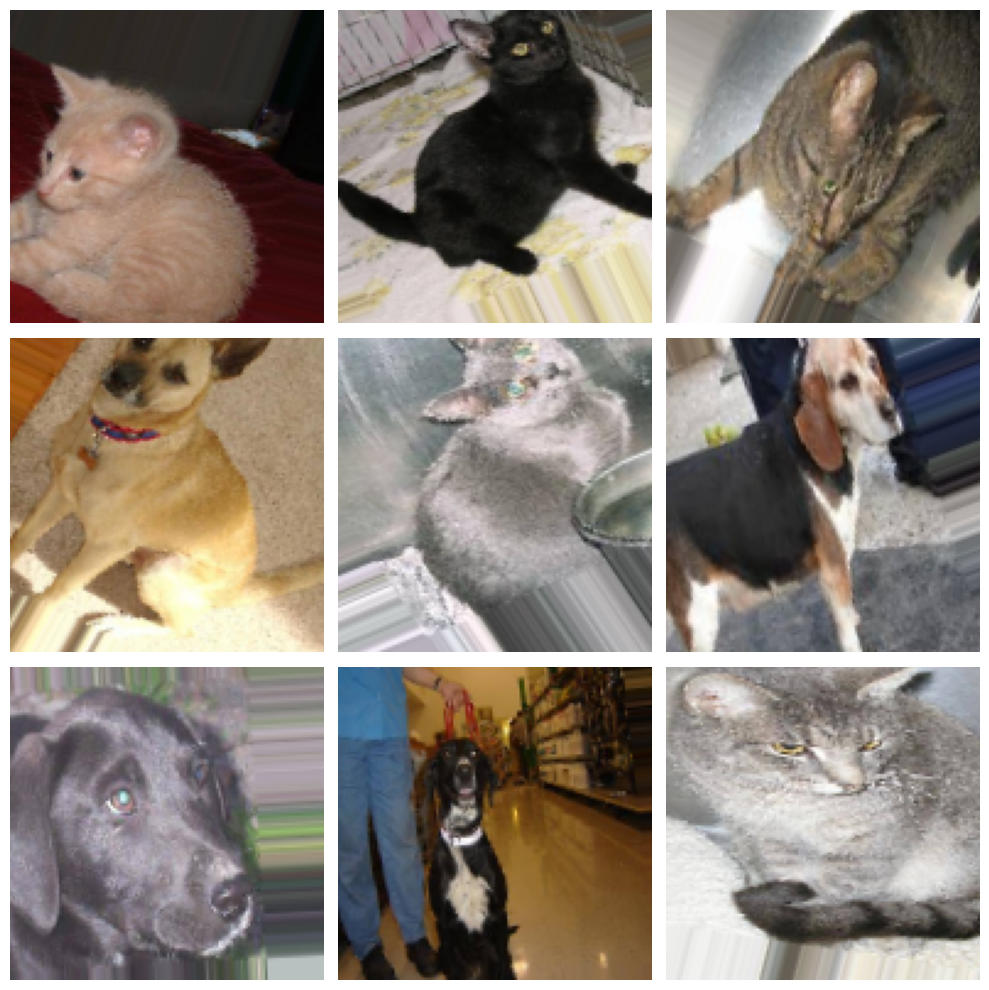

In [ ]:
# Obtener un lote del generador
images, labels = next(train_generator)  # Siguiente lote

# Mostrar las primeras 9 imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Test

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    data_dir_test,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',   # Usa el mismo class_mode que en entrenamiento
    shuffle=False,              # ¡Importante para evaluar o predecir!
    seed = seed
)

Found 5000 images belonging to 2 classes.


## Generación y ajuste del modelo

#### Definición de arquitectura `VGG16`

In [ ]:
"""model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))"""

#### Arquitectura resumida

In [ ]:
model = Sequential()
# Entrada
model.add(Input(shape=(128, 128, 3)))
# 1era capa oculta
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# 2da capa oculta
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# 3era capa oculta
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# 4ta capa oculta
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
# Salida
model.add(Dense(2, activation='softmax'))


#### Compilamos

In [24]:
model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])
model

<Sequential name=sequential_2, built=True>

#### Generamos un callback de early_stop

In [29]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True
                           )

#### Entrenamos el modelo

In [30]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop] 
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 263ms/step - accuracy: 0.7076 - loss: 0.5606 - val_accuracy: 0.7617 - val_loss: 0.4853
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 267ms/step - accuracy: 0.7683 - loss: 0.4930 - val_accuracy: 0.7837 - val_loss: 0.4516
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 154s 309ms/step - accuracy: 0.8010 - loss: 0.4360 - val_accuracy: 0.8092 - val_loss: 0.4106
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 311ms/step - accuracy: 0.8298 - loss: 0.3837 - val_accuracy: 0.8192 - val_loss: 0.4057
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 211ms/step - accuracy: 0.8474 - loss: 0.3492 - val_accuracy: 0.8117 - val_loss: 0.4240
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 161ms/step - accuracy: 0.8610 - loss: 0.3135 - val_accuracy: 0.8265 - val_loss: 0.4156
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.8836 - loss: 0.2625 - val_accuracy: 0.8393 - val_loss: 0.3864
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.9007 - lo

#### Métricas para train

In [33]:
_, accuracy = model.evaluate(train_generator)

500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.9290 - loss: 0.1848


In [34]:
accuracy

0.9257500171661377

## Predicción

In [38]:
y_pred = model.predict(test_generator)
y_pred[:15]

157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step


array([[9.9742246e-01, 2.5775812e-03],
       [9.9524695e-01, 4.7530471e-03],
       [7.7710003e-01, 2.2289999e-01],
       [9.9134070e-01, 8.6592762e-03],
       [7.9369766e-01, 2.0630231e-01],
       [9.9667680e-01, 3.3231983e-03],
       [4.9394959e-01, 5.0605047e-01],
       [5.2872491e-01, 4.7127503e-01],
       [9.6610582e-01, 3.3894140e-02],
       [7.6364845e-01, 2.3635150e-01],
       [9.9991727e-01, 8.2728147e-05],
       [9.9910969e-01, 8.9034636e-04],
       [8.6988997e-01, 1.3011004e-01],
       [9.9971324e-01, 2.8670012e-04],
       [9.9921417e-01, 7.8579917e-04]], dtype=float32)

In [57]:
y_pred_round = [[round(x,0) for x in val] for val in y_pred]
y_pred_round[:15]

[[1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0]]

#### Métricas para test

In [36]:
test_loss, test_acc = model.evaluate(test_generator, verbose=2)

157/157 - 36s - 231ms/step - accuracy: 0.8446 - loss: 0.3801


In [37]:
print('\nTest accuracy:', test_acc)


Test accuracy: 0.8446000218391418


### Conclusiones
>- Con la arquitectura completa de vgg16 los tiempos de entrenamiento son muy altos, al reestructurar la arquitectura podemos reducir en un alto porcentaje los tiempos de carga
>- Con 10 epocas de entrenamiento conseguimos una precisión bastante competente para el conjunto de test, podemos mejorarlo con más épocas y optimizando(ajuste fino)


## Guardar modelo

In [58]:
model.save("keras_128x128-16-32_64-64-2.keras")